In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install -q torch torchaudio pandas numpy tqdm easydict matplotlib seaborn scikit-learn

In [ ]:
%%bash

ARCHIVE="/content/drive/MyDrive/data/processed_v10_safe_precomputed.tar"
LOCAL_ROOT="/content/processed_v10_safe"

mkdir -p "$LOCAL_ROOT"

cp "$ARCHIVE" /content/processed_v10_safe_precomputed.tar
tar -xf /content/processed_v10_safe_precomputed.tar -C "$LOCAL_ROOT"

echo "Number of feature files:"
find "$LOCAL_ROOT/precomputed" -name "*.pt" | wc -l

Number of feature files:
9894


In [ ]:
import os
import json
import math
import time
import random
import shutil
import warnings
from pathlib import Path
from contextlib import nullcontext
from typing import Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from easydict import EasyDict
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

Cấu hình:

In [ ]:
DRIVE_ROOT = Path('/content/drive/MyDrive')

DATA_ROOT = DRIVE_ROOT / 'data/processed_v10_safe'
METADATA_PATH = DATA_ROOT / 'all_metadata.csv'
PRECOMPUTED_DIR = DATA_ROOT / 'precomputed'

OUTPUT_ROOT = DRIVE_ROOT / 'motionemo_v10_phase1'
CHECKPOINT_DIR = OUTPUT_ROOT / 'checkpoints'
EVAL_DIR = OUTPUT_ROOT / 'eval'

for p in [OUTPUT_ROOT, CHECKPOINT_DIR, EVAL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# cấu hình Pha 1
cfg = EasyDict({
    'audio': {
        'n_mels': 80,       # Số dải mel;
        'max_frames': 500,
    },

    'model': {
        'embedding_dim': 512,
        'num_heads': 8,
        'num_layers': 6,
        'dropout': 0.1,
    },

    'masking': {
        'mask_prob': 0.25,       # Che khoảng 25% frame
        'min_span': 4,
        'max_span': 16,
        'min_mask_frames': 8,
        'mask_value': 0.0,
        'mask_prosody_input': True, # Che cả mel và prosody
    },

    'loss': {
        'lambda_mel_masked': 1.0,
        'lambda_prosody_masked': 0.5,
        'lambda_mel_valid_light': 0.05,
        'lambda_prosody_valid_light': 0.05,
    },

    'training': {
        'epochs': 60,
        'batch_size': 16,
        'grad_accum_steps': 4,
        'base_lr': 1e-4,
        'min_lr': 1e-6,
        'weight_decay': 1e-4,
        'warmup_epochs': 3,
        'plateau_patience': 6,
        'plateau_factor': 0.5,
        'early_stop_patience': 12,
        'grad_clip': 1.0,          # Chặn exploding gradient trong Transformer.
        'num_workers': 2,
        'device': 'cuda' if torch.cuda.is_available() else 'cpu',
        'use_amp': True,
        'seed': 42,
    },

    'runtime': {
        'prefer_local_precomputed': True,
        'local_precomputed_dir': '/content/processed_v10_safe/precomputed',

        'auto_copy_precomputed_to_local': False,

        'resume': True,
    }
})

Seed và AMP context

In [ ]:
# cố định random seed
def set_seed(seed: int = 42):
    """Cố định seed cho Python, NumPy và PyTorch; giúp quá trình training dễ tái lập."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(cfg.training.seed)

# GPU CUDA
def autocast_context():
    if amp_enabled and device == 'cuda':
        return torch.amp.autocast('cuda', enabled=True)
    return nullcontext()

Dataset và collate function cho Pha 1:
Dataset đọc các feature `.pt` đã tiền tính, crop/pad về `max_frames`, và trả về mel + prosody cho nhiệm vụ masked reconstruction.

In [ ]:
# Class đọc feature .pt đã tiền tính và trả về mel + prosody cho Pha 1.
class Phase1Dataset(Dataset):
    """Dataset Pha 1: load mel, F0, energy, speaking_rate; crop/pad theo max_frames."""

    # Hàm khởi tạo lưu metadata, giới hạn frame và chế độ crop.
    def __init__(self, df_data: pd.DataFrame, max_frames: int = 500, deterministic_crop: bool = False):
        """deterministic_crop=True dùng cho validation để kết quả đánh giá ổn định hơn."""
        self.df = df_data.reset_index(drop=True)
        self.max_frames = max_frames
        self.deterministic_crop = deterministic_crop

    # Hàm cho DataLoader biết tổng số mẫu trong split.
    def __len__(self):
        """Trả về số dòng metadata tương ứng số mẫu audio/feature."""
        return len(self.df)

    # Hàm chọn điểm bắt đầu crop khi feature dài hơn max_frames.
    def _crop_start(self, T: int) -> int:
        """Train crop ngẫu nhiên để tăng đa dạng; validation crop giữa đoạn để ổn định."""
        if T <= self.max_frames:
            return 0
        if self.deterministic_crop:
            return max(0, (T - self.max_frames) // 2)
        return random.randint(0, T - self.max_frames)

    # Hàm load một mẫu feature, cắt về max_frames nếu cần và trả về dict cho collate_fn.
    def __getitem__(self, idx: int) -> Dict[str, Any]:
        """Đọc một file feature .pt và chuẩn hóa shape đầu ra cho DataLoader."""
        row = self.df.iloc[idx]
        path = Path(row['feature_path'])

        # Feature được tạo từ data_pipeline: mel (M,T), f0/energy/speaking_rate (T,).
        data = torch.load(path, map_location='cpu', weights_only=False)

        mel = data['mel'].float()
        f0 = data['f0'].float()
        energy = data['energy'].float()
        srate = data['speaking_rate'].float()

        T = mel.shape[1]

        # Nếu mẫu quá dài, chỉ lấy một cửa sổ max_frames để batch có chiều dài kiểm soát được.
        if T > self.max_frames:
            start = self._crop_start(T)
            end = start + self.max_frames
            mel = mel[:, start:end]
            f0 = f0[start:end]
            energy = energy[start:end]
            srate = srate[start:end]

        length = mel.shape[1]

        return {
            'mel': mel,
            'f0': f0,
            'energy': energy,
            'srate': srate,
            'length': length,
            'sample_id': row['sample_id'],
            'dataset': row['dataset'],
        }


# Hàm gom nhiều sample có độ dài khác nhau thành batch bằng padding về max_len trong batch.
def collate_fn(batch):
    """Pad mel/prosody theo chiều thời gian để tạo batch tensor cho Transformer."""
    max_len = max(item['length'] for item in batch)

    mels, f0s, energies, srates = [], [], [], []
    lengths = []
    sample_ids, datasets = [], []

    for item in batch:
        pad = max_len - item['length']

        # Pad bên phải theo trục thời gian; padding positions sẽ được mask bằng lengths.
        mel = F.pad(item['mel'], (0, pad))
        f0 = F.pad(item['f0'], (0, pad))
        energy = F.pad(item['energy'], (0, pad))
        srate = F.pad(item['srate'], (0, pad))

        mels.append(mel.unsqueeze(0))
        f0s.append(f0.unsqueeze(0))
        energies.append(energy.unsqueeze(0))
        srates.append(srate.unsqueeze(0))
        lengths.append(item['length'])
        sample_ids.append(item['sample_id'])
        datasets.append(item['dataset'])

    return {
        'mel': torch.cat(mels, dim=0),
        'f0': torch.cat(f0s, dim=0),
        'energy': torch.cat(energies, dim=0),
        'srate': torch.cat(srates, dim=0),
        'lengths': torch.tensor(lengths, dtype=torch.long),
        'sample_id': sample_ids,
        'dataset': datasets,
    }

Tạo mask theo span và masked MSE

In [ ]:
# Hàm tạo padding mask cho Transformer: True nghĩa là vị trí padding cần bỏ qua.
def make_padding_mask(lengths: torch.Tensor, max_len: int) -> torch.Tensor:
    """Tạo mask (B,T) với True tại các frame nằm ngoài độ dài thật của từng mẫu."""
    idx = torch.arange(max_len, device=lengths.device).unsqueeze(0)
    return idx >= lengths.unsqueeze(1)


# Hàm tạo valid mask: True nghĩa là frame thật, không phải padding.
def make_valid_mask(lengths: torch.Tensor, max_len: int) -> torch.Tensor:
    """Đảo của padding mask; dùng để tính loss trên các frame hợp lệ."""
    return ~make_padding_mask(lengths, max_len)


# Hàm này tạo mask theo các span liên tiếp để mô phỏng nhiệm vụ masked reconstruction.
def make_span_mask(lengths: torch.Tensor, max_len: int, cfg_mask: EasyDict, device: str) -> torch.Tensor:
    """Tạo mask (B,T) với True tại vùng frame bị che; chỉ mask trong vùng hợp lệ."""
    B = lengths.shape[0]
    mask = torch.zeros(B, max_len, dtype=torch.bool, device=device)

    for b in range(B):
        L = int(lengths[b].item())
        if L <= 0:
            continue

        # Số frame cần che dựa trên mask_prob nhưng không thấp hơn min_mask_frames.
        target = max(cfg_mask.min_mask_frames, int(round(L * cfg_mask.mask_prob)))
        target = min(target, L)

        masked = 0
        attempts = 0
        max_attempts = max(10, target * 3)

        # Lặp nhiều lần để đặt các span ngẫu nhiên cho đến khi đủ số frame cần che.
        while masked < target and attempts < max_attempts:
            attempts += 1
            span = random.randint(cfg_mask.min_span, cfg_mask.max_span)
            span = min(span, L)
            start = random.randint(0, max(0, L - span))
            end = min(L, start + span)

            before = int(mask[b, :L].sum().item())
            mask[b, start:end] = True
            after = int(mask[b, :L].sum().item())
            masked += max(0, after - before)

        # Đảm bảo mỗi mẫu có ít nhất một frame bị che để loss không bị rỗng.
        if mask[b, :L].sum() == 0:
            mask[b, random.randint(0, L - 1)] = True

    return mask

# Hàm áp dụng mask lên mel và tùy chọn lên cả prosody đầu vào.
def apply_mask_to_inputs(mel, f0, energy, srate, mask, mask_value=0.0, mask_prosody_input=True):
    """Thay frame bị che bằng 0 để mô hình phải suy ra lại từ ngữ cảnh còn lại."""
    # mel có shape (B,M,T), nên mask (B,T) được unsqueeze theo kênh mel.
    mel_masked = mel.masked_fill(mask.unsqueeze(1), mask_value)

    # Nếu không che prosody, mô hình có thể nhìn thấy đáp án prosody tại vùng cần tái tạo.
    if mask_prosody_input:
        f0_masked = f0.masked_fill(mask, 0.0)
        energy_masked = energy.masked_fill(mask, 0.0)
        srate_masked = srate.masked_fill(mask, 0.0)
    else:
        f0_masked = f0
        energy_masked = energy
        srate_masked = srate

    return mel_masked, f0_masked, energy_masked, srate_masked


# Hàm tính MSE cho tensor dạng channel-first như mel: (B,C,T).
def masked_mse_3d_channel_first(pred, target, mask_bt):
    """Tính MSE chỉ tại các vị trí mask cho tensor (B,C,T)."""
    if mask_bt.sum() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
    mask = mask_bt.unsqueeze(1).expand_as(pred)
    return F.mse_loss(pred[mask], target[mask])


# Hàm tính MSE cho tensor dạng channel-last như prosody_hat: (B,T,C).
def masked_mse_3d_channel_last(pred, target, mask_bt):
    """Tính MSE chỉ tại các vị trí mask cho tensor (B,T,C)."""
    if mask_bt.sum() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
    mask = mask_bt.unsqueeze(-1).expand_as(pred)
    return F.mse_loss(pred[mask], target[mask])


In [ ]:
Backbone và decoder pha 1:

In [ ]:
# Class backbone này mã hóa mel + prosody thành H_frame và H_utt.
# đây là bộ mã hóa nền được dùng ở cả Pha 1 và Pha 2.
class MotionEmoBackboneV10(nn.Module):
    """Backbone hai nhánh: prosody encoder + mel encoder + fusion + Transformer + attention pooling."""

    # Hàm khởi tạo định nghĩa toàn bộ kiến trúc backbone.
    def __init__(self, n_mels=80, embed_dim=512, num_heads=8, num_layers=6, dropout=0.1):
        """n_mels khớp feature; embed_dim là kích thước biểu diễn chung sau fusion."""
        super().__init__()

        # Nhánh prosody học biến thiên F0/energy/speaking_rate theo thời gian.
        self.prosody_encoder = nn.Sequential(
            nn.Conv1d(3, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
        )

        # Nhánh mel học cấu trúc phổ-thời gian từ mel-spectrogram.
        self.mel_encoder = nn.Sequential(
            nn.Conv1d(n_mels, 256, kernel_size=5, padding=2),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
        )

        # Ghép hai nhánh 256+256 rồi chiếu về embed_dim để đưa vào Transformer.
        self.fusion_proj = nn.Sequential(
            nn.Linear(512, embed_dim),
            nn.LayerNorm(embed_dim),
        )

        # Transformer học quan hệ dài hơn giữa các frame, có padding mask để bỏ qua vùng pad.
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
            activation='gelu',
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Attention pooling học trọng số cho từng frame để tạo embedding mức đoạn H_utt.
        self.attn_pool = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 4),
            nn.Tanh(),
            nn.Linear(embed_dim // 4, 1),
        )

    # Hàm forward nhận mel/prosody và trả về biểu diễn mức frame + mức đoạn.
    def forward(self, mel, f0, energy, srate, lengths: Optional[torch.Tensor] = None):
        """mel: (B,M,T), prosody: (B,T); output H_frame: (B,T,D), H_utt: (B,D)."""
        B, _, T = mel.shape

        # Ghép ba chuỗi prosody thành tensor (B,3,T) cho Conv1D.
        prosody_in = torch.stack([f0, energy, srate], dim=1)

        # Mã hóa từng nhánh riêng để giữ cả thông tin phổ và thông tin ngữ điệu.
        p_feat = self.prosody_encoder(prosody_in)
        m_feat = self.mel_encoder(mel)

        # Ghép kênh và đổi sang (B,T,D) cho Transformer.
        fused = torch.cat([p_feat, m_feat], dim=1)
        x = self.fusion_proj(fused.transpose(1, 2))  # (B, T, D)

        # Padding mask giúp Transformer không chú ý vào vùng pad.
        pad_mask = None
        if lengths is not None:
            pad_mask = make_padding_mask(lengths, T)

        H_frame = self.transformer(x, src_key_padding_mask=pad_mask)

        # Attention pooling: frame quan trọng hơn đóng góp nhiều hơn vào H_utt.
        attn_logits = self.attn_pool(H_frame).squeeze(-1)

        if pad_mask is not None:
            attn_logits = attn_logits.masked_fill(pad_mask, -1e4)

        attn = torch.softmax(attn_logits, dim=1).unsqueeze(-1)
        H_utt = (attn * H_frame).sum(dim=1)

        return H_frame, H_utt


# Decoder này tái tạo mel từ H_frame trong Pha 1.
class StrongDecoder(nn.Module):
    """Mel decoder dùng Conv1D 1x1 để biến H_frame thành mel_hat (B,n_mels,T)."""

    # Hàm khởi tạo decoder mel.
    def __init__(self, embed_dim=512, n_mels=80):
        """embed_dim phải khớp backbone; n_mels phải khớp mel target."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(embed_dim, 512, kernel_size=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Conv1d(512, 512, kernel_size=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Conv1d(512, n_mels, kernel_size=1),
        )

    # Hàm forward đổi H_frame từ (B,T,D) sang (B,D,T) rồi dự đoán mel.
    def forward(self, H_frame):
        """Trả về mel_hat có shape (B,n_mels,T)."""
        return self.net(H_frame.transpose(1, 2))


# Predictor này tái tạo ba kênh prosody từ H_frame.
class ProsodyPredictor(nn.Module):
    """Dự đoán lại [F0, energy, speaking_rate] cho từng frame."""

    # Hàm khởi tạo MLP nhỏ cho prosody.
    def __init__(self, embed_dim=512):
        """Đầu ra có 3 chiều tương ứng F0, energy, speaking_rate."""
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Linear(256, 3),
        )

    # Hàm forward giữ shape thời gian: (B,T,D) -> (B,T,3).
    def forward(self, H_frame):
        """Trả về prosody_hat có shape (B,T,3)."""
        return self.net(H_frame)

Hàm tính loss và lưu/load checkpoint

In [ ]:
# Hàm tính toàn bộ loss Pha 1 cho một batch.
# Đây là lõi của Pha 1: che mel/prosody, đưa qua backbone, rồi yêu cầu mô hình tái tạo vùng bị che.
def compute_phase1_losses(batch, train_mode: bool = True):
    """Trả về loss tổng và các metric phụ: mel masked, prosody masked, valid loss, mask_ratio."""
    # Bước 1: đưa batch lên GPU/CPU đang dùng.
    mel = batch['mel'].to(device, non_blocking=True)
    f0 = batch['f0'].to(device, non_blocking=True)
    energy = batch['energy'].to(device, non_blocking=True)
    srate = batch['srate'].to(device, non_blocking=True)
    lengths = batch['lengths'].to(device, non_blocking=True)

    # 2: tạo valid_mask để biết frame thật và span mask để biết vùng bị che.
    B, _, T = mel.shape
    valid_mask = make_valid_mask(lengths, T)
    mask = make_span_mask(lengths, T, cfg.masking, device)

    # 3: che đầu vào. Target vẫn là mel/prosody gốc chưa che.
    mel_in, f0_in, energy_in, srate_in = apply_mask_to_inputs(
        mel, f0, energy, srate,
        mask=mask,
        mask_value=cfg.masking.mask_value,
        mask_prosody_input=cfg.masking.mask_prosody_input,
    )

    # 4: mã hóa đầu vào bị che để tạo H_frame/H_utt.
    H_frame, H_utt = backbone(mel_in, f0_in, energy_in, srate_in, lengths=lengths)

    # 5: decoder tái tạo mel; prosody predictor tái tạo F0/energy/speaking_rate.
    mel_hat = decoder(H_frame)
    prosody_hat = prosody_pred(H_frame)
    prosody_target = torch.stack([f0, energy, srate], dim=-1)

    # 6: loss chính chỉ tính trên vùng bị che.
    loss_mel_masked = masked_mse_3d_channel_first(mel_hat, mel, mask)
    loss_prosody_masked = masked_mse_3d_channel_last(prosody_hat, prosody_target, mask)

    # 7: loss phụ rất nhẹ trên toàn vùng hợp lệ để output ngoài mask không bị tùy ý.
    loss_mel_valid = masked_mse_3d_channel_first(mel_hat, mel, valid_mask)
    loss_prosody_valid = masked_mse_3d_channel_last(prosody_hat, prosody_target, valid_mask)

    # 8: tổng hợp loss theo trọng số cấu hình.
    loss = (
        cfg.loss.lambda_mel_masked * loss_mel_masked +
        cfg.loss.lambda_prosody_masked * loss_prosody_masked +
        cfg.loss.lambda_mel_valid_light * loss_mel_valid +
        cfg.loss.lambda_prosody_valid_light * loss_prosody_valid
    )

    # Metrics được detach để log mà không giữ graph, tránh tốn memory.
    metrics = {
        'loss_total': loss,
        'loss_mel_masked': loss_mel_masked.detach(),
        'loss_prosody_masked': loss_prosody_masked.detach(),
        'loss_mel_valid': loss_mel_valid.detach(),
        'loss_prosody_valid': loss_prosody_valid.detach(),
        'mask_ratio': (mask.sum().float() / valid_mask.sum().float().clamp_min(1)).detach(),
    }

    return loss, metrics

# Hàm lưu toàn bộ trạng thái cần thiết để resume hoặc dùng checkpoint tốt nhất cho Pha 2.
def save_checkpoint(path: Path, epoch: int, best_val_loss: float, patience_counter: int, history: Dict[str, Any]):
    """Lưu state_dict của model, optimizer, scheduler, scaler và history training."""
    torch.save({
        'backbone': backbone.state_dict(),
        'decoder': decoder.state_dict(),
        'prosody_pred': prosody_pred.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'cfg': dict(cfg),
        'epoch': epoch,
        'best_val_loss': best_val_loss,
        'patience_counter': patience_counter,
        'history': history,
        'data_root': str(DATA_ROOT),
        'metadata_path': str(METADATA_PATH),
    }, path)

# Hàm load checkpoint để resume training hoặc kiểm tra checkpoint đã lưu.
def load_checkpoint(path: Path):
    """Nạp lại model/optimizer/scheduler từ checkpoint Pha 1."""
    ckpt = torch.load(path, map_location=device, weights_only=False)

    backbone.load_state_dict(ckpt['backbone'])
    decoder.load_state_dict(ckpt['decoder'])
    prosody_pred.load_state_dict(ckpt['prosody_pred'])

    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])

    # GradScaler chỉ nên load khi đang dùng CUDA; nếu chạy CPU thì bỏ qua an toàn.
    if device == 'cuda' and 'scaler' in ckpt:
        scaler.load_state_dict(ckpt['scaler'])
    else:
        print('Skip scaler state loading because device is not CUDA or scaler missing.')

    return ckpt


Device: cuda
AMP: True
Data root: /content/drive/MyDrive/data/processed_v10_safe
Metadata: /content/drive/MyDrive/data/processed_v10_safe/all_metadata.csv
Output: /content/drive/MyDrive/motionemo_v10_phase1
auto_copy_precomputed_to_local = False
If local cache already exists, it will be used automatically.
Using local precomputed cache: /content/processed_v10_safe/precomputed
Sample feature path: /content/processed_v10_safe/precomputed/iemocap__ed571c739b5a__Ses01F_impro01_F000.pt
Exists: True

Dataset size: 9894

Split x Dataset
dataset  crema  iemocap  ravdess
split                           
test       947      560      144
train     4273     1731      574
val        950      571      144

Split x Emotion
emotion  anger  fear  happiness  neutral  sadness
split                                            
test       243   233        432      432      311
train     1191  1010       1560     1430     1387
val        315   228        378      383      361
Speaker overlap train/val: 0
Spe

Phase1 Epoch 001:   0%|          | 0/412 [00:00<?, ?it/s]

Validate 001:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 001 | Train 0.8882 | Val 0.6704 | TrainMel 0.4857 | ValMel 0.3269 | TrainPros 0.6794 | ValPros 0.6033 | LR 3.33e-05
✓ Best Phase 1 checkpoint saved


Phase1 Epoch 002:   0%|          | 0/412 [00:00<?, ?it/s]

...

Validate 059:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 059 | Train 0.4502 | Val 0.4533 | TrainMel 0.2095 | ValMel 0.2103 | TrainPros 0.4563 | ValPros 0.4617 | LR 2.50e-05
No improvement. Patience 2/12


Phase1 Epoch 060:   0%|          | 0/412 [00:00<?, ?it/s]

Validate 060:   0%|          | 0/105 [00:00<?, ?it/s]

Epoch 060 | Train 0.4518 | Val 0.4555 | TrainMel 0.2091 | ValMel 0.2115 | TrainPros 0.4603 | ValPros 0.4638 | LR 2.50e-05
No improvement. Patience 3/12
Phase 1 training finished.
Best val loss: 0.45141252421197436
Best checkpoint: /content/drive/MyDrive/motionemo_v10_phase1/checkpoints/best_phase1_v10.pt


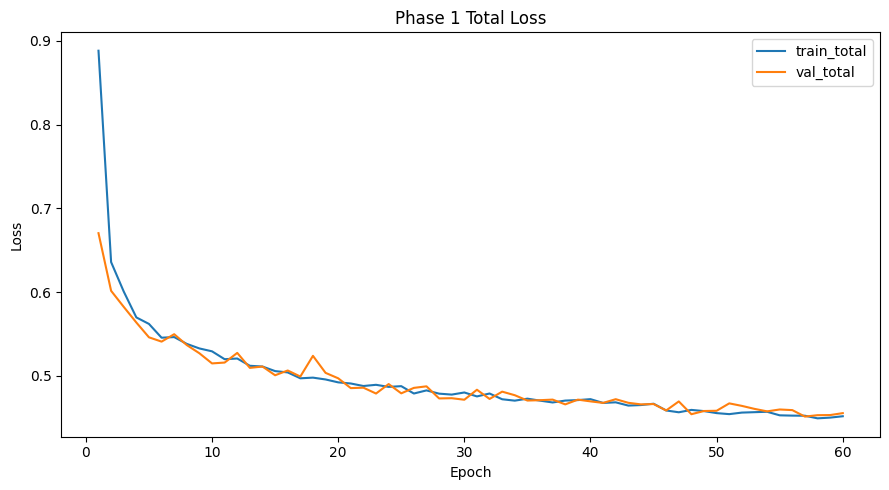

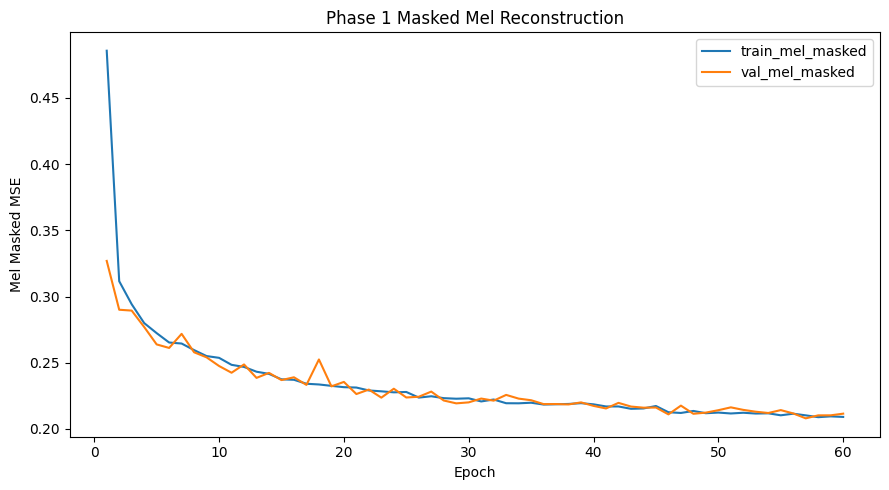

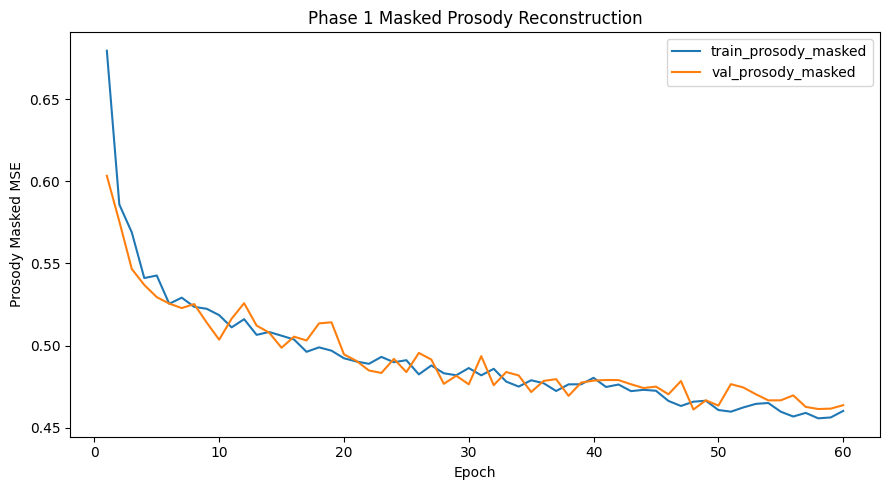

Saved plots to: /content/drive/MyDrive/motionemo_v10_phase1/eval
Best checkpoint loaded successfully.
Epoch: 57
Best val loss: 0.45141252421197436
Keys: dict_keys(['backbone', 'decoder', 'prosody_pred', 'optimizer', 'scheduler', 'scaler', 'cfg', 'epoch', 'best_val_loss', 'patience_counter', 'history', 'data_root', 'metadata_path'])


In [ ]:
device = cfg.training.device
amp_enabled = bool(cfg.training.use_amp and device == 'cuda')

print('Device:', device)
print('AMP:', amp_enabled)
print('Data root:', DATA_ROOT)
print('Metadata:', METADATA_PATH)
print('Output:', OUTPUT_ROOT)

# Local cache
LOCAL_PRECOMP = Path(cfg.runtime.local_precomputed_dir)

if cfg.runtime.auto_copy_precomputed_to_local:
    LOCAL_PRECOMP.mkdir(parents=True, exist_ok=True)
    print('Copying precomputed features to local cache...')
    !rsync -ah --info=progress2 "{PRECOMPUTED_DIR}/" "{LOCAL_PRECOMP}/"
else:
    print('auto_copy_precomputed_to_local = False')
    print('If local cache already exists, it will be used automatically.')

# Load metadata vaf kieemr tra
if not METADATA_PATH.exists():
    raise FileNotFoundError(f'Metadata not found: {METADATA_PATH}')

df = pd.read_csv(METADATA_PATH)

required_cols = [
    'sample_id', 'feature_id', 'dataset', 'speaker_uid', 'speaker_label',
    'emotion', 'emotion_label', 'split', 'feature_path', 'duration_final',
    'lufs_final', 'num_frames'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise RuntimeError(f'Metadata missing columns: {missing}')

# local cache
if cfg.runtime.prefer_local_precomputed and LOCAL_PRECOMP.exists():
    print('Using local precomputed cache:', LOCAL_PRECOMP)
    df['feature_path'] = df['feature_path'].apply(lambda p: str(LOCAL_PRECOMP / Path(p).name))
else:
    print('Using Drive feature paths.')

sample_path = Path(df.iloc[0]['feature_path'])
print('Sample feature path:', sample_path)
print('Exists:', sample_path.exists())

if not sample_path.exists():
    raise RuntimeError(
        'Sample feature file does not exist. Either set auto_copy_precomputed_to_local=True, '
        'or disable prefer_local_precomputed, or check paths.'
    )

# Lightweight sanity checks.
print('\nDataset size:', len(df))
print('\nSplit x Dataset')
print(pd.crosstab(df['split'], df['dataset']))
print('\nSplit x Emotion')
print(pd.crosstab(df['split'], df['emotion']))

for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    A = set(df[df['split'] == a]['speaker_uid'])
    B = set(df[df['split'] == b]['speaker_uid'])
    overlap = A & B
    print(f'Speaker overlap {a}/{b}: {len(overlap)}')
    if overlap:
        raise RuntimeError(f'Speaker leakage detected: {a}/{b}')

# Test load one feature file.
obj = torch.load(sample_path, map_location='cpu', weights_only=False)
print('\nSample feature keys:', sorted(obj.keys()))
print('Sample mel shape:', obj['mel'].shape)

# DATALOADERS
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)

test_df = df[df['split'] == 'test'].reset_index(drop=True)

train_ds = Phase1Dataset(train_df, max_frames=cfg.audio.max_frames, deterministic_crop=False)
val_ds = Phase1Dataset(val_df, max_frames=cfg.audio.max_frames, deterministic_crop=True)

loader_kwargs = {
    'num_workers': cfg.training.num_workers,
    'pin_memory': (device == 'cuda'),
}

if cfg.training.num_workers > 0:
    loader_kwargs.update({
        'persistent_workers': True,
        'prefetch_factor': 2,
    })

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.training.batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    **loader_kwargs
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.training.batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    **loader_kwargs
)

print(f'Train samples: {len(train_ds)} | Val samples: {len(val_ds)}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

batch = next(iter(train_loader))
print('Batch mel:', batch['mel'].shape)
print('Batch lengths:', batch['lengths'][:5])

# INIT MODEL / OPTIMIZER
backbone = MotionEmoBackboneV10(
    n_mels=cfg.audio.n_mels,
    embed_dim=cfg.model.embedding_dim,
    num_heads=cfg.model.num_heads,
    num_layers=cfg.model.num_layers,
    dropout=cfg.model.dropout,
).to(device)

decoder = StrongDecoder(
    embed_dim=cfg.model.embedding_dim,
    n_mels=cfg.audio.n_mels,
).to(device)

prosody_pred = ProsodyPredictor(
    embed_dim=cfg.model.embedding_dim,
).to(device)

params = list(backbone.parameters()) + list(decoder.parameters()) + list(prosody_pred.parameters())

optimizer = torch.optim.AdamW(
    params,
    lr=cfg.training.base_lr,
    weight_decay=cfg.training.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=cfg.training.plateau_factor,
    patience=cfg.training.plateau_patience,
    min_lr=cfg.training.min_lr,
)

scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

print('Backbone parameters:', sum(p.numel() for p in backbone.parameters()) / 1e6, 'M')
print('Total parameters:', sum(p.numel() for p in params) / 1e6, 'M')

# RESUME IF AVAILABLE
LAST_CKPT = CHECKPOINT_DIR / 'last_phase1_v10.pt'
BEST_CKPT = CHECKPOINT_DIR / 'best_phase1_v10.pt'

start_epoch = 1
best_val_loss = float('inf')
patience_counter = 0

history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'train_mel_masked': [],
    'val_mel_masked': [],
    'train_prosody_masked': [],
    'val_prosody_masked': [],
    'train_mask_ratio': [],
    'val_mask_ratio': [],
    'lr': [],
}

if cfg.runtime.resume and LAST_CKPT.exists():
    print('Resuming from:', LAST_CKPT)
    ckpt = load_checkpoint(LAST_CKPT)
    start_epoch = int(ckpt['epoch']) + 1
    best_val_loss = float(ckpt.get('best_val_loss', best_val_loss))
    patience_counter = int(ckpt.get('patience_counter', 0))
    history = ckpt.get('history', history)
    print(f'Resumed at epoch {start_epoch}, best_val_loss={best_val_loss:.6f}')
else:
    print('Starting Phase 1 training from scratch.')

# TRAINING LOOP
for epoch in range(start_epoch, cfg.training.epochs + 1):
    # Linear warmup.
    if epoch <= cfg.training.warmup_epochs:
        lr = cfg.training.base_lr * epoch / max(1, cfg.training.warmup_epochs)
        for pg in optimizer.param_groups:
            pg['lr'] = lr

    backbone.train()
    decoder.train()
    prosody_pred.train()

    optimizer.zero_grad(set_to_none=True)

    train_sums = {
        'loss': 0.0,
        'mel_masked': 0.0,
        'prosody_masked': 0.0,
        'mask_ratio': 0.0,
    }

    pbar = tqdm(train_loader, desc=f'Phase1 Epoch {epoch:03d}')

    for step, batch in enumerate(pbar):
        with autocast_context():
            loss, metrics = compute_phase1_losses(batch, train_mode=True)
            loss_scaled = loss / cfg.training.grad_accum_steps

        scaler.scale(loss_scaled).backward()

        if (step + 1) % cfg.training.grad_accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(params, cfg.training.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        train_sums['loss'] += float(metrics['loss_total'].detach().cpu())
        train_sums['mel_masked'] += float(metrics['loss_mel_masked'].cpu())
        train_sums['prosody_masked'] += float(metrics['loss_prosody_masked'].cpu())
        train_sums['mask_ratio'] += float(metrics['mask_ratio'].cpu())

        pbar.set_postfix({
            'loss': f"{float(metrics['loss_total'].detach().cpu()):.4f}",
            'mel': f"{float(metrics['loss_mel_masked'].cpu()):.4f}",
            'pros': f"{float(metrics['loss_prosody_masked'].cpu()):.4f}",
            'mask': f"{float(metrics['mask_ratio'].cpu()):.2f}",
        })

    # xử lý gradient còn dư nếu số batch không chia hết cho grad_accum_steps
    if len(train_loader) % cfg.training.grad_accum_steps != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(params, cfg.training.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_train_loss = train_sums['loss'] / len(train_loader)
    avg_train_mel = train_sums['mel_masked'] / len(train_loader)
    avg_train_pros = train_sums['prosody_masked'] / len(train_loader)
    avg_train_mask = train_sums['mask_ratio'] / len(train_loader)

    # Validation
    backbone.eval()
    decoder.eval()
    prosody_pred.eval()

    val_sums = {
        'loss': 0.0,
        'mel_masked': 0.0,
        'prosody_masked': 0.0,
        'mask_ratio': 0.0,
    }

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Validate {epoch:03d}'):
            with autocast_context():
                loss, metrics = compute_phase1_losses(batch, train_mode=False)

            val_sums['loss'] += float(metrics['loss_total'].detach().cpu())
            val_sums['mel_masked'] += float(metrics['loss_mel_masked'].cpu())
            val_sums['prosody_masked'] += float(metrics['loss_prosody_masked'].cpu())
            val_sums['mask_ratio'] += float(metrics['mask_ratio'].cpu())

    avg_val_loss = val_sums['loss'] / len(val_loader)
    avg_val_mel = val_sums['mel_masked'] / len(val_loader)
    avg_val_pros = val_sums['prosody_masked'] / len(val_loader)
    avg_val_mask = val_sums['mask_ratio'] / len(val_loader)

    # giảm LR nếu validation loss không cải thiện
    if epoch > cfg.training.warmup_epochs:
        scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(
        f'Epoch {epoch:03d} | '
        f'Train {avg_train_loss:.4f} | Val {avg_val_loss:.4f} | '
        f'TrainMel {avg_train_mel:.4f} | ValMel {avg_val_mel:.4f} | '
        f'TrainPros {avg_train_pros:.4f} | ValPros {avg_val_pros:.4f} | '
        f'LR {current_lr:.2e}'
    )

    history['epoch'].append(epoch)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_mel_masked'].append(avg_train_mel)
    history['val_mel_masked'].append(avg_val_mel)
    history['train_prosody_masked'].append(avg_train_pros)
    history['val_prosody_masked'].append(avg_val_pros)
    history['train_mask_ratio'].append(avg_train_mask)
    history['val_mask_ratio'].append(avg_val_mask)
    history['lr'].append(current_lr)

    pd.DataFrame(history).to_csv(EVAL_DIR / 'phase1_history.csv', index=False)

    # save last checkpoint.
    save_checkpoint(
        LAST_CKPT,
        epoch=epoch,
        best_val_loss=best_val_loss,
        patience_counter=patience_counter,
        history=history,
    )

    # Save best checkpoint.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        save_checkpoint(
            BEST_CKPT,
            epoch=epoch,
            best_val_loss=best_val_loss,
            patience_counter=patience_counter,
            history=history,
        )
        print('✓ Best Phase 1 checkpoint saved')
    else:
        patience_counter += 1
        print(f'No improvement. Patience {patience_counter}/{cfg.training.early_stop_patience}')
        if patience_counter >= cfg.training.early_stop_patience:
            print('Early stopping triggered.')
            break

print('Phase 1 training finished.')
print('Best val loss:', best_val_loss)
print('Best checkpoint:', BEST_CKPT)


# PLOT
hist_path = EVAL_DIR / 'phase1_history.csv'
if hist_path.exists():
    hist = pd.read_csv(hist_path)

    plt.figure(figsize=(9, 5))
    plt.plot(hist['epoch'], hist['train_loss'], label='train_total')
    plt.plot(hist['epoch'], hist['val_loss'], label='val_total')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Phase 1 Total Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'phase1_total_loss.png', dpi=160)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(hist['epoch'], hist['train_mel_masked'], label='train_mel_masked')
    plt.plot(hist['epoch'], hist['val_mel_masked'], label='val_mel_masked')
    plt.xlabel('Epoch')
    plt.ylabel('Mel Masked MSE')
    plt.title('Phase 1 Masked Mel Reconstruction')
    plt.legend()
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'phase1_mel_masked_loss.png', dpi=160)
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(hist['epoch'], hist['train_prosody_masked'], label='train_prosody_masked')
    plt.plot(hist['epoch'], hist['val_prosody_masked'], label='val_prosody_masked')
    plt.xlabel('Epoch')
    plt.ylabel('Prosody Masked MSE')
    plt.title('Phase 1 Masked Prosody Reconstruction')
    plt.legend()
    plt.tight_layout()
    plt.savefig(EVAL_DIR / 'phase1_prosody_masked_loss.png', dpi=160)
    plt.show()

    print('Saved plots to:', EVAL_DIR)
else:
    print('No history found.')


# QUICK CHECK: LOAD BEST CHECKPOINT
if BEST_CKPT.exists():
    ckpt = torch.load(BEST_CKPT, map_location=device, weights_only=False)
    print('Best checkpoint loaded successfully.')
    print('Epoch:', ckpt.get('epoch'))
    print('Best val loss:', ckpt.get('best_val_loss'))
    print('Keys:', ckpt.keys())
else:
    print('Best checkpoint not found.')
